# GR-Prediction — Local Eval (Compact **Stateful** Discretized LSTM)

Evaluates models trained by
[`train_lstm_compact_stateful_discretized.ipynb`](train_lstm_compact_stateful_discretized.ipynb)
(`model_type == "stateful_frame_rate_lstm_discretized"`).

This is a **separate** eval notebook from `eval_lstm_discretized.ipynb`, which is
hardwired to the older `FrameRateLSTMGR` (different state-dict keys, `hop_size`
stored under `lstm`, hardcoded 151 bins). This version targets the compact
stateful model and differs in four ways:

- **Architecture**: `StatefulFrameRateLSTMGR` (single strided `proj` conv ->
  PReLU -> single LSTM -> single `Linear` head), loaded by stripping the
  `model.` prefix from the Lightning checkpoint.
- **Bin count read from `hparams.json`** (`discretization.num_bins` /
  `bin_resolution_db`) — works for 151 @ 0.2 dB, 61 @ 0.5 dB, etc., nothing
  hardcoded.
- **Stateful inference**: predictions warm the LSTM with a multi-second pre-roll
  (single-window viz) or carry hidden state **across chunks** (whole-song audio
  metrics), matching the TBPTT training regime instead of cold-starting.
- **`hop_size` read from the top level** of `hparams.json`.

Features: list runs, plot BCE/MAE curves, predict GR on any pair with a bin
heatmap, and compute duration-weighted validation audio metrics.

> Requirements: `uv sync` at repo root.

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import os, sys, glob, json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import lightning as pl

warnings.filterwarnings("ignore", category=UserWarning)

from src.dsp_torch import (
    GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
    gain_reduction_db,
)
from src import dsp_torch

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"

# Set SELECTED_RUN_NAME in the run-selection cell after available runs are listed.

SAMPLE_RATE = 44100
DEVICE = "cpu"


from eval_helpers import _checkpoint_sort_key, latest_best_checkpoint, list_runs


print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"Shared GR DSP helpers: {dsp_torch.__file__}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
Shared GR DSP helpers: /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/src/dsp_torch.py


In [2]:
# == 1. List available compact-stateful LSTM runs ==

assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

MODEL_TYPE = "stateful_frame_rate_lstm_discretized"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs found in {RUNS_DIR}.\n"
    "Train one first with train_lstm_compact_stateful_discretized.ipynb."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available compact-stateful LSTM runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Available compact-stateful LSTM runs: 2


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
15,lstm_gr_20260605_152452_lstm_compact_stateful_...,stateful_frame_rate_lstm_discretized,93.0,0.153314,19,best-034-16660.ckpt,2026-06-10 12:16:26.353250027
26,lstm_gr_20260610_120709_lstm_compact_stateful_...,stateful_frame_rate_lstm_discretized,499.0,0.126900,54,best-475-226576.ckpt,2026-06-10 12:30:25.836910725


In [3]:
# == 2. Select run and checkpoint ==

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = "lstm_gr_20260610_120709_lstm_compact_stateful_cosine_longer_training"

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Model type     : {selected_run['type']}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

Selected run   : lstm_gr_20260610_120709_lstm_compact_stateful_cosine_longer_training
Model type     : stateful_frame_rate_lstm_discretized
Eval checkpoint: best-475-226576.ckpt
Best val loss  : 0.126900


In [4]:
# ── 2. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : lstm_gr_20260610_120709_lstm_compact_stateful_cosine_longer_training
Eval checkpoint: best-475-226576.ckpt
Checkpoints    :
  last.ckpt                               0.10 MB
  epoch-009.ckpt                          0.10 MB
  epoch-019.ckpt                          0.10 MB
  epoch-029.ckpt                          0.10 MB
  epoch-039.ckpt                          0.10 MB
  epoch-049.ckpt                          0.10 MB
  epoch-059.ckpt                          0.10 MB
  epoch-069.ckpt                          0.10 MB
  epoch-079.ckpt                          0.10 MB
  epoch-089.ckpt                          0.10 MB
  epoch-099.ckpt                          0.10 MB
  epoch-109.ckpt                          0.10 MB
  epoch-119.ckpt                          0.10 MB
  epoch-129.ckpt                          0.10 MB
  epoch-139.ckpt                          0.10 MB
  epoch-149.ckpt                          0.10 MB
  epoch-159.ckpt                          0.10 MB
  epoch-1

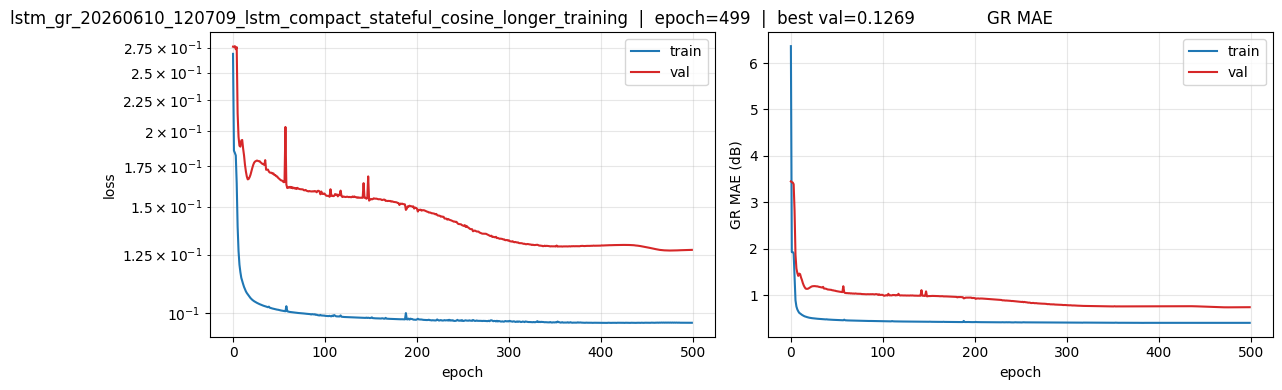

In [5]:
# ── 3. Loss curves ──────────────────────────────────────────────────

def plot_loss_curves(run_dir=None, ymin=None):
    run_dir = run_dir or RUN_DIR
    csv_path = os.path.join(run_dir, "csv", "metrics.csv")
    if not os.path.exists(csv_path):
        print(f"No metrics.csv yet at {csv_path}")
        return
    df = pd.read_csv(csv_path)

    has_mae = "mae_db/val" in df.columns and df["mae_db/val"].notna().any()
    n_cols = 2 if has_mae else 1

    fig, axes = plt.subplots(1, n_cols, figsize=(8 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    # BCE loss
    ax = axes[0]
    train = df.dropna(subset=["loss/train"])[["epoch", "loss/train"]]
    val = df.dropna(subset=["loss/val"])[["epoch", "loss/val"]]
    ax.plot(train["epoch"], train["loss/train"], label="train", lw=1.5, color="#1f77b4")
    ax.plot(val["epoch"], val["loss/val"], label="val", lw=1.5, color="#d62728")
    ax.set_xlabel("epoch")
    ax.set_ylabel("BCE loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    last_epoch = int(max(train["epoch"].max() if len(train) else -1,
                         val["epoch"].max() if len(val) else -1))
    best_val = float(val["loss/val"].min()) if len(val) else float("nan")
    ax.set_title(f"BCE loss | epoch={last_epoch} | best val={best_val:.4f}")
    if ymin is not None:
        ax.set_ylim(bottom=ymin)

    # dB MAE
    if has_mae:
        ax2 = axes[1]
        mae_tr = df.dropna(subset=["mae_db/train"])[["epoch", "mae_db/train"]]
        mae_va = df.dropna(subset=["mae_db/val"])[["epoch", "mae_db/val"]]
        ax2.plot(mae_tr["epoch"], mae_tr["mae_db/train"], label="train", lw=1.5, color="#1f77b4")
        ax2.plot(mae_va["epoch"], mae_va["mae_db/val"], label="val", lw=1.5, color="#d62728")
        ax2.set_xlabel("epoch")
        ax2.set_ylabel("MAE (dB)")
        ax2.grid(alpha=0.3)
        ax2.legend()
        best_mae = float(mae_va["mae_db/val"].min()) if len(mae_va) else float("nan")
        ax2.set_title(f"dB MAE | best val={best_mae:.2f} dB")

    fig.suptitle(os.path.basename(run_dir), fontsize=11)
    plt.tight_layout()
    plt.show()
    return df

from eval_helpers import plot_loss_curves

_ = plot_loss_curves(RUN_DIR)

In [6]:
# == 4. Model definition & checkpoint loading (compact stateful LSTM) ==
#
# Discretization (num_bins / resolution) is READ FROM hparams.json per run, so
# this works for any bin count the training notebook used (151@0.2, 61@0.5, ...).

class StatefulFrameRateLSTMGR(nn.Module):
    """Compact stateful frame-rate LSTM with CREPE-style discretized output.
    Mirrors train_lstm_compact_stateful_discretized.ipynb."""

    def __init__(self, hop_size=256, encoder_channels=8, hidden_size=24,
                 num_layers=1, num_bins=151):
        super().__init__()
        self.hop_size = hop_size
        self.num_bins = num_bins
        self.proj = nn.Conv1d(1, encoder_channels, kernel_size=hop_size, stride=hop_size)
        self.act  = nn.PReLU(encoder_channels)
        self.lstm = nn.LSTM(encoder_channels, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, num_bins)

    def forward(self, dry, state=None, return_state=False):
        x = self.act(self.proj(dry)).transpose(1, 2)   # [B, T_frames, C]
        x, state = self.lstm(x, state)
        logits = self.head(x).transpose(1, 2)          # [B, num_bins, T_frames]
        return (logits, state) if return_state else logits

    def local_avg_db(self, logits, window=5):
        """Bin logits -> continuous dB via local weighted average around argmax."""
        probs = torch.sigmoid(logits)
        centers = torch.linspace(GR_DB_MIN, GR_DB_MAX, self.num_bins, device=logits.device)
        peak = probs.argmax(dim=1)
        B, N, T = probs.shape
        bin_idx = torch.arange(N, device=logits.device).view(1, N, 1).expand(B, N, T)
        lo = (peak.unsqueeze(1) - window).clamp(min=0)
        hi = (peak.unsqueeze(1) + window + 1).clamp(max=N)
        mask = (bin_idx >= lo) & (bin_idx < hi)
        masked = probs * mask
        weighted = (masked * centers[None, :, None]).sum(dim=1, keepdim=True)
        total = masked.sum(dim=1, keepdim=True).clamp(min=1e-8)
        return weighted / total

    def to_db(self, logits, T=None, window=5):
        db = self.local_avg_db(logits, window)
        if T is not None:
            db = F.interpolate(db, size=T, mode="linear", align_corners=False)
        return db


from eval_helpers import _find_hparams_json


def build_model_from_hparams(hp):
    h = hp["lstm"]
    d = hp.get("discretization", {})
    return StatefulFrameRateLSTMGR(
        hop_size=int(hp.get("hop_size", h.get("hop_size", 256))),
        encoder_channels=int(h["encoder_channels"]),
        hidden_size=int(h["hidden_size"]),
        num_layers=int(h["num_layers"]),
        num_bins=int(d.get("num_bins", 151)),
    )


def load_model_from_ckpt(ckpt_path, hparams_path=None):
    """Build the model from hparams and load weights (strip Lightning 'model.')."""
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), f"hparams.json not found near {ckpt_path}"
    with open(hparams_path) as f:
        hp = json.load(f)

    expected = hp.get("src_dsp_torch_sha256")
    if expected:
        import hashlib as _hl
        local = _hl.sha256(Path(dsp_torch.__file__).read_bytes()).hexdigest()
        if local != expected:
            print("[warning] local src.dsp_torch differs from checkpoint's version")

    model = build_model_from_hparams(hp)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    sd = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    model_sd = {k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")}
    model.load_state_dict(model_sd)        # strict: architecture must match exactly
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Loaded {model.num_bins}-bin model, {n_params:,} params, hop={model.hop_size}")
    return model, hp


print("Model builder registered: stateful_frame_rate_lstm_discretized")

Model builder registered: stateful_frame_rate_lstm_discretized


In [7]:
# == 5. Evaluation & visualisation functions (stateful) ==
#
# Single-window prediction warms the LSTM over a `pre_roll_sec` context fed in
# the SAME forward pass (a causal LSTM run over [start - pre_roll : stop] is
# state-warm by the time it reaches `start`), then crops to the requested window.

from eval_helpers import _read_dry_wet_segment, same_setting_pairs

DEFAULT_PRE_ROLL_SEC = 10.0   # generous warm-up for the stateful LSTM


@torch.no_grad()
def predict_gr_curves(ckpt_path, dry_wav_path, wet_wav_path, start_sec=0.0,
                      duration_sec=6.0, hparams_path=None,
                      pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    model, hp = load_model_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"]); rms_win = int(hp["rms_window"]); hop = model.hop_size

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    pre_roll = int(round(pre_roll_sec * sr))
    context_start = max(0, start - pre_roll)
    context_offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_wav_path, wet_wav_path, context_start, stop, sr)

    gr_target_db = gain_reduction_db(
        dry.unsqueeze(0), wet.unsqueeze(0), rms_win
    ).squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)

    x = dry.unsqueeze(0).to(DEVICE)
    logits = model(x)                                   # warms over pre-roll
    gr_pred_db = model.to_db(logits, T=dry.shape[-1]).squeeze(0)

    n = min(stop - start, dry.shape[-1] - context_offset,
            gr_target_db.shape[-1] - context_offset, gr_pred_db.shape[-1] - context_offset)
    assert n > 0
    w = slice(context_offset, context_offset + n)
    gr_true = gr_target_db[..., w].squeeze().cpu().numpy()
    gr_pred = gr_pred_db[..., w].squeeze().cpu().numpy()
    dry_wave = dry[..., w].squeeze().cpu().numpy()

    probs_full = torch.sigmoid(logits).squeeze(0).cpu()
    frame_start = context_offset // hop
    frame_end = min((context_offset + n) // hop + 1, probs_full.shape[1])
    bin_probs = probs_full[:, frame_start:frame_end].numpy()

    err = gr_pred - gr_true
    song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
    return {
        "song": song, "setting": hp["setting"],
        "model_type": hp.get("model_type", "stateful_frame_rate_lstm_discretized"),
        "ckpt": ckpt_path, "sample_rate": sr,
        "start_sec": start_sec, "duration_sec": n / sr,
        "pre_roll_sec": context_offset / sr,
        "time": np.arange(n) / sr,
        "dry": dry_wave, "gr_true": gr_true, "gr_pred": gr_pred, "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "bin_probs": bin_probs, "hop_size": hop, "hparams": hp,
    }


@torch.no_grad()
def visualize_prediction(ckpt_path, dry_wav_path=None, wet_wav_path=None,
                         start_sec=0.0, duration_sec=6.0, hparams_path=None,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None, show_heatmap=True):
    _, hp = load_model_from_ckpt(ckpt_path, hparams_path)
    setting = hp["setting"]
    pairs = same_setting_pairs(DATA_ROOT, setting)
    if dry_wav_path is None:
        dry_wav_path, wet_wav_path = pairs[0]
    elif wet_wav_path is None:
        song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
        wet_wav_path = os.path.join(DATA_ROOT, "processed_ground_truth", setting, f"{song}-exported.wav")

    curves = predict_gr_curves(
        ckpt_path=ckpt_path, dry_wav_path=dry_wav_path, wet_wav_path=wet_wav_path,
        start_sec=start_sec, duration_sec=duration_sec,
        hparams_path=hparams_path, pre_roll_sec=pre_roll_sec,
    )

    t = curves["time"]
    n_rows = 4 if show_heatmap else 3
    ratios = [1, 2, 1, 2] if show_heatmap else [1, 2, 1]
    fig, axes = plt.subplots(n_rows, 1, figsize=(11, 3 * n_rows - 2), sharex=True,
                             gridspec_kw={"height_ratios": ratios})

    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("GR (dB)"); axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)"); axes[2].grid(alpha=0.3)

    if show_heatmap:
        probs = curves["bin_probs"]
        extent = [t[0], t[-1], GR_DB_MIN, GR_DB_MAX]
        im = axes[3].imshow(probs, aspect="auto", origin="lower", extent=extent,
                            cmap="magma", vmin=0, vmax=1, interpolation="bilinear")
        axes[3].plot(t, curves["gr_true"], color="cyan", lw=0.8, alpha=0.8, label="target")
        axes[3].plot(t, curves["gr_pred"], color="lime", lw=0.8, alpha=0.8, label="predicted")
        axes[3].set_ylabel("GR (dB)"); axes[3].legend(loc="lower right", fontsize=8)
        fig.colorbar(im, ax=axes[3], label="P(bin)", shrink=0.8)

    axes[-1].set_xlabel("time (s)")
    ttl = title or (
        f"{curves['song']}  |  {curves['model_type']}  |  {curves['setting']}\n"
        f"ckpt={os.path.basename(ckpt_path)}  pre-roll={curves['pre_roll_sec']:.2f}s  "
        f"MAE={curves['mae_db']:.2f} dB  RMSE={curves['rmse_db']:.2f} dB"
    )
    fig.suptitle(ttl, fontsize=10); plt.tight_layout(); plt.show()
    return curves


def compare_same_setting_curves(ckpt_path, start_sec=30.0, duration_sec=5.0,
                                max_pairs=2, start_pair=5, hparams_path=None,
                                show_heatmap=True):
    _, hp = load_model_from_ckpt(ckpt_path, hparams_path)
    pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
    selected = pairs[start_pair:max_pairs + start_pair]
    print(f"Comparing {len(selected)} of {len(pairs)} pairs")
    return [
        visualize_prediction(ckpt_path=ckpt_path, dry_wav_path=d, wet_wav_path=w,
                             start_sec=start_sec, duration_sec=duration_sec,
                             hparams_path=hparams_path, show_heatmap=show_heatmap)
        for d, w in selected
    ]

## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the following selection cell.

Set `show_heatmap=False` to hide the bin probability panel.

Running best-475-226576.ckpt
[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256
[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256


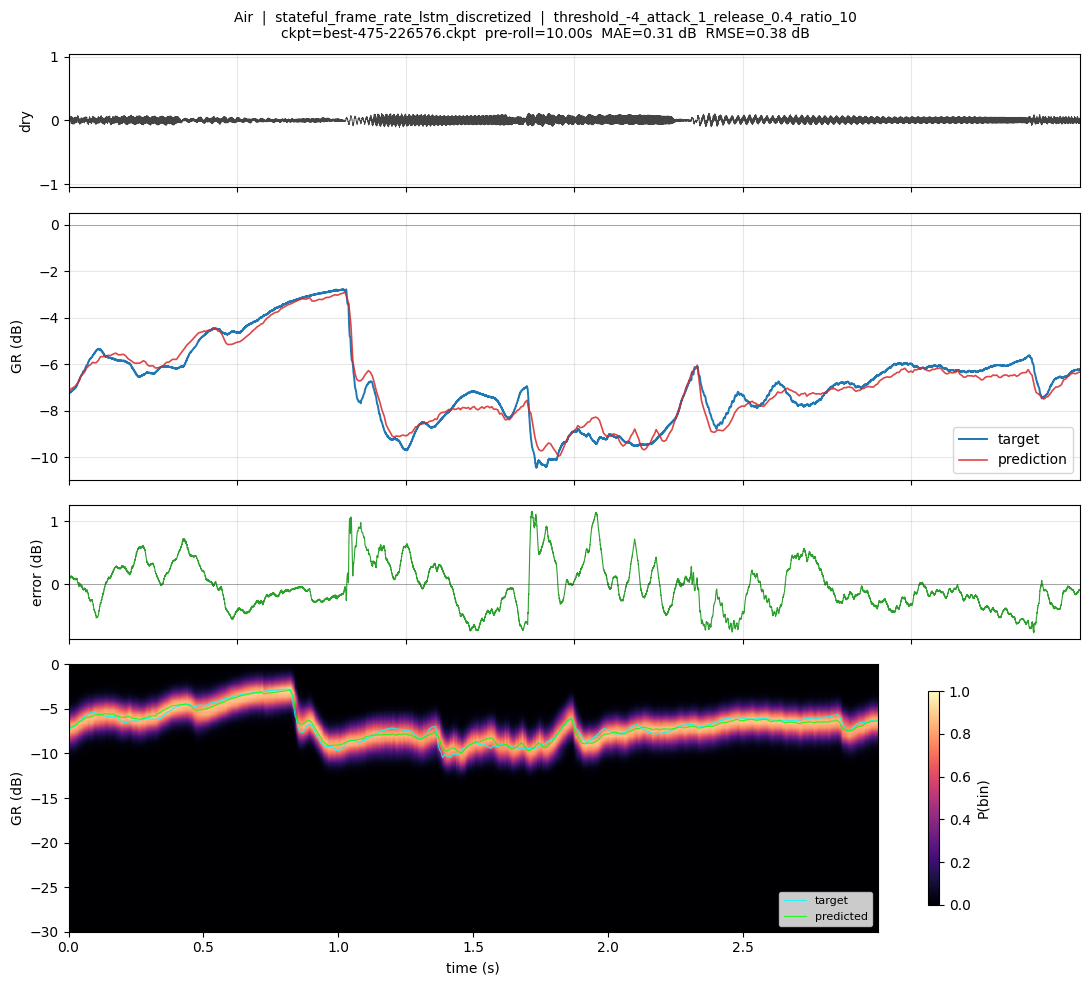

In [8]:
# Single prediction preview
print(f"Running {os.path.basename(EVAL_CKPT_PATH)}")

_ = visualize_prediction(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=30.0,
    duration_sec=3.0,
)

[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256
Comparing 3 of 10 pairs
[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256
[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256


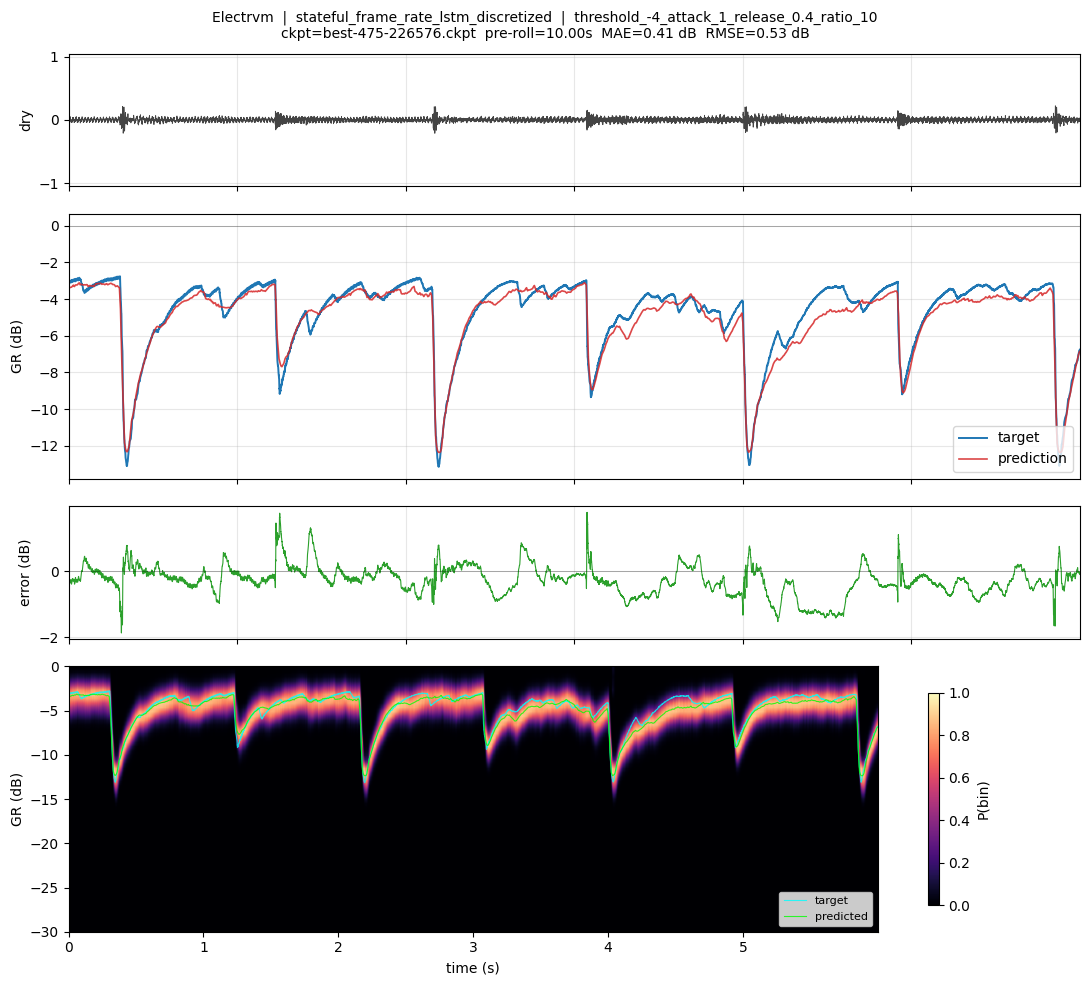

[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256
[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256


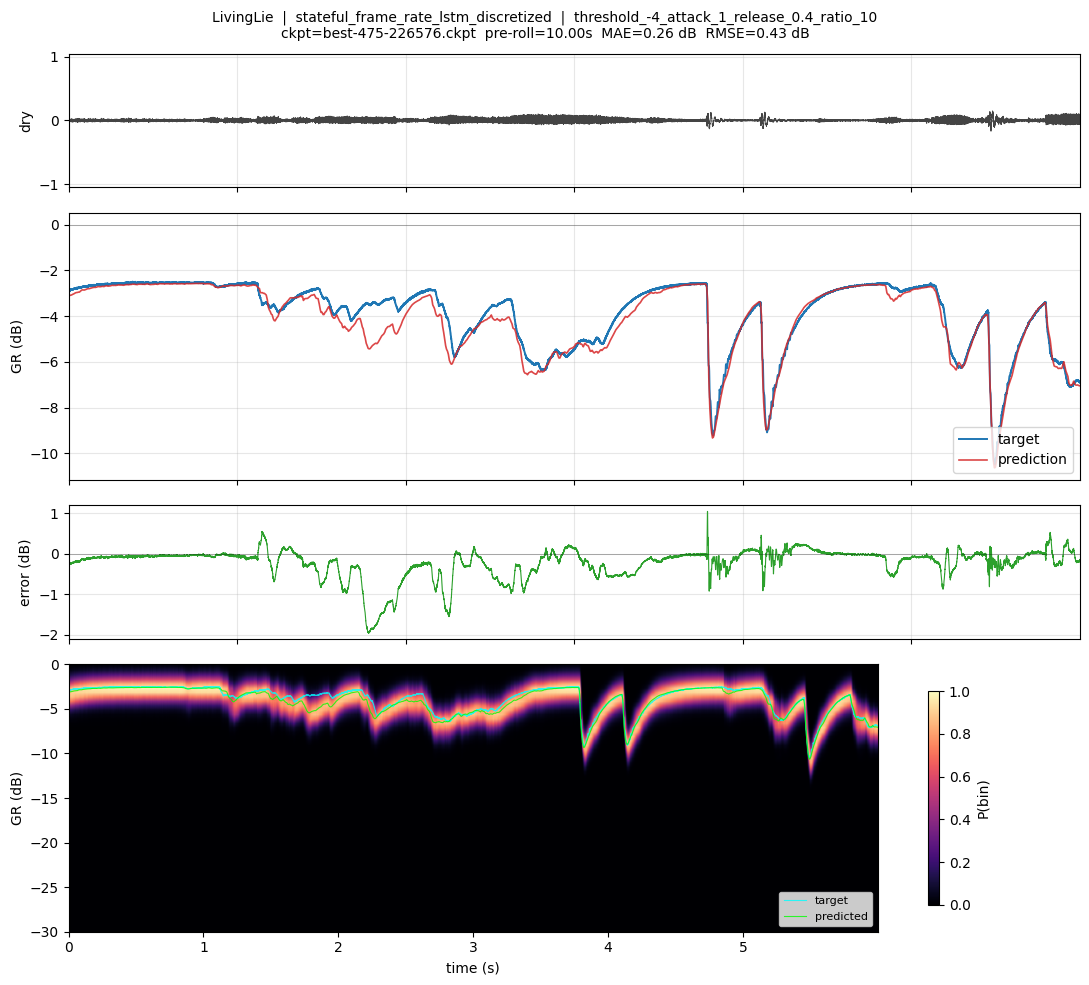

[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256
[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256


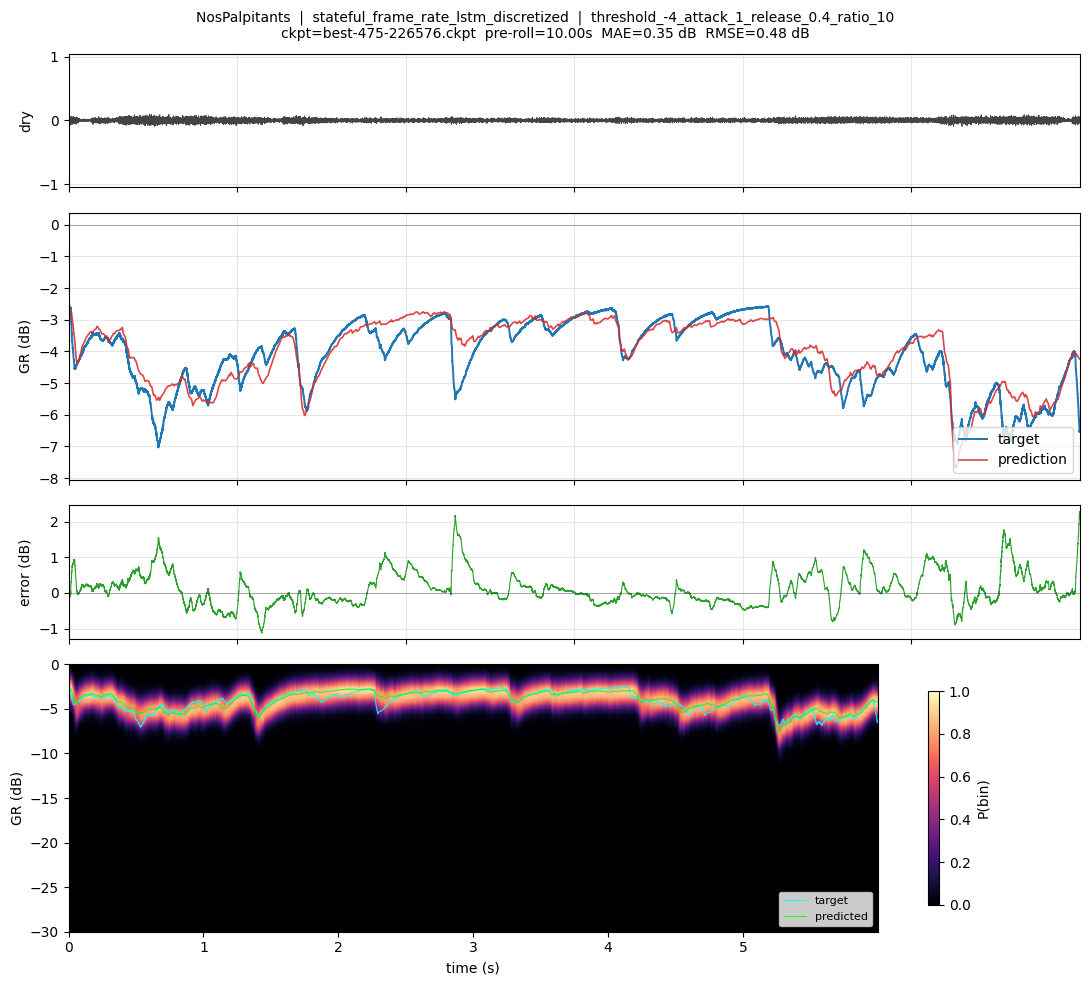

In [9]:
# Compare across multiple songs
results = compare_same_setting_curves(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    max_pairs=3,
)

In [10]:
# == 6. Validation-set audio metrics (TRUE stateful streaming) ==
#
# Reconstructs the song-level validation split used in training, then streams
# each song through the model in chunks with the LSTM hidden state CARRIED
# across chunks (matching TBPTT training).  Wet audio is reconstructed as
# dry * 10**(GR_dB/20); metrics are duration-weighted over all chunks.

import gc
from pathlib import Path

import pandas as pd
import soundfile as sf
import torch

from src.losses import compute_all_losses as compute_audio_losses
from eval_helpers import (
    _db_to_amplitude, _pair_num_frames, _song_from_dry_path,
    _validation_pairs_from_training_split, _weighted_average_metric_rows,
)

# None -> full validation split. Small int for a smoke test; list for a subset.
MAX_VALIDATION_SONGS: int | None = None
EVAL_VALIDATION_SONGS: list[str] | None = None
STREAM_CHUNK_SEC = 10.0          # chunk size; LSTM state carried across chunks
SAVE_CHUNK_METRICS = False

model, hp = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"]); device = torch.device(DEVICE); hop = model.hop_size
chunk_frames = int(round(STREAM_CHUNK_SEC * sr)); chunk_frames -= chunk_frames % hop
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

all_pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)
if EVAL_VALIDATION_SONGS is not None:
    sel = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [(d, w) for d, w in eval_pairs if _song_from_dry_path(d) in sel]
if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]
assert eval_pairs, "No validation pairs selected."


@torch.no_grad()
def stream_song_metrics(model, dry_path, wet_path, sr, chunk_frames, device):
    """Stateful pass over a whole song; returns per-chunk metric rows."""
    total = _pair_num_frames(dry_path, wet_path, sr)
    state = None
    rows = []
    for ci, o in enumerate(range(0, total, chunk_frames), start=1):
        stop = min(o + chunk_frames, total)
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, sr)
        L = dry.shape[-1] - (dry.shape[-1] % hop)
        if L < hop:
            break
        dry, wet = dry[..., :L], wet[..., :L]
        x = dry.unsqueeze(0).to(device)
        logits, state = model(x, state, return_state=True)
        state = (state[0].detach(), state[1].detach())     # carry across chunks
        gr_db = model.to_db(logits, T=L).clamp(GR_DB_MIN, GR_DB_MAX).squeeze(0).cpu()
        pred_wet = dry * _db_to_amplitude(gr_db)
        losses = compute_audio_losses(pred_wet.unsqueeze(0), wet.unsqueeze(0))
        rows.append({"Chunk": ci, "Start (s)": o / sr, "Duration (s)": L / sr,
                     "Frames": L, **losses})
        del dry, wet, x, logits, gr_db, pred_wet
        if device.type == "cuda":
            torch.cuda.empty_cache()
    return rows


validation_chunk_rows = []
for i, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    total_frames = _pair_num_frames(dry_path, wet_path, sr)
    print(f"[{i}/{len(eval_pairs)}] {song} ({total_frames / sr:.1f}s, "
          f"stateful chunks of {STREAM_CHUNK_SEC:.1f}s)")
    for row in stream_song_metrics(model, dry_path, wet_path, sr, chunk_frames, device):
        validation_chunk_rows.append({"Song": song, **row})
    gc.collect()

assert validation_chunk_rows, "No validation chunks were evaluated."

weighted_metrics = _weighted_average_metric_rows(validation_chunk_rows, metric_cols)
total_frames = sum(r["Frames"] for r in validation_chunk_rows)
validation_metrics_df = pd.DataFrame([{
    "Split": "validation", "Songs": len(eval_pairs),
    "Chunks": len(validation_chunk_rows), "Duration (s)": total_frames / sr,
    **weighted_metrics,
}])

validation_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation.csv"
validation_metrics_df.to_csv(validation_metrics_path, index=False)
print(f"Saved validation audio metrics -> {validation_metrics_path}")
if SAVE_CHUNK_METRICS:
    chunk_path = Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv"
    pd.DataFrame(validation_chunk_rows).to_csv(chunk_path, index=False)
    print(f"Saved validation chunk metrics -> {chunk_path}")

display(validation_metrics_df)

[warning] local src.dsp_torch differs from checkpoint's version
Loaded 61-bin model, 6,853 params, hop=256
Validation split: 2 validation songs, 8 train songs (seed=42, train_split=0.8)
Validation songs: ['Borderline', 'NosPalpitants']
[1/2] Borderline (273.9s, stateful chunks of 10.0s)
[2/2] NosPalpitants (198.1s, stateful chunks of 10.0s)
Saved validation audio metrics -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260610_120709_lstm_compact_stateful_cosine_longer_training/eval_audio_metrics_validation.csv


,Split,Songs,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,2,48,471.968798,0.001864,0.000008,0.036889,0.100025,0.189691,0.126256,0.149089
